In [3]:
import pandas as pd
import json
import os

root_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
json_path_candidates = [
    os.path.join(root_dir, 'archive', 'raw_posts.json'),
    os.path.join(root_dir, 'raw_posts.json'),
    '/content/raw_posts.json'
]

json_path = next((p for p in json_path_candidates if os.path.exists(p)), None)
if json_path is None:
    raise FileNotFoundError(f"Could not find raw_posts.json in expected locations: {json_path_candidates}")

print('Using JSON file:', json_path)

try:
    with open(json_path, 'r', encoding='utf-8', errors='ignore') as f:
        json_content = f.read()

    data = json.loads(json_content)
    if not isinstance(data, list):
        raise ValueError('Expected JSON top-level object to be a list of records')
    df = pd.DataFrame(data)
except (json.JSONDecodeError, ValueError):
    data = []
    with open(json_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    df = pd.DataFrame(data)
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise

if df.empty:
    print('DataFrame is empty after loading. Check raw_posts.json content.')
else:
    print('Dataset Preview:')
    print(df.head())

if 'text' not in df.columns or 'engagement' not in df.columns:
    raise KeyError("Expected columns 'text' and 'engagement' in data")

# Create a platform indicator if missing
if 'Platform' not in df.columns:
    df['Platform'] = df['text'].apply(lambda x: 'LinkedIn' if 'LinkedIn' in str(x) else 'Other')

result = df.groupby('Platform')['engagement'].sum().reset_index()
result.rename(columns={'engagement': 'Total Engagement'}, inplace=True)

print("\nTotal Engagement per Platform:")
print(result)

if not result.empty:
    max_engagement_platform = result.loc[result['Total Engagement'].idxmax()]
    print("\nPlatform with Highest Engagement:", max_engagement_platform['Platform'], "(", max_engagement_platform['Total Engagement'], "total engagement )")
else:
    print("\nNo engagement data available for analysis.")


Using JSON file: c:\Users\Raja Banerjee\Desktop\Data_Analytics\archive\raw_posts.json
Dataset Preview:
                                                text  engagement
0  Just saw a LinkedIn Influencer with 'Organic G...          90
1  Jobseekers, this one’s for you.\n Every applic...         347
2  Looking for jobs on LinkedIn is like online da...         109
3  LinkedIn scams be like: 'Congratulations, you'...         115
4  sapne dekhna achi baat hai,\nlekin job ka sapn...         545

Total Engagement per Platform:
   Platform  Total Engagement
0  LinkedIn              2102
1     Other             23136

Platform with Highest Engagement: Other ( 23136 total engagement )


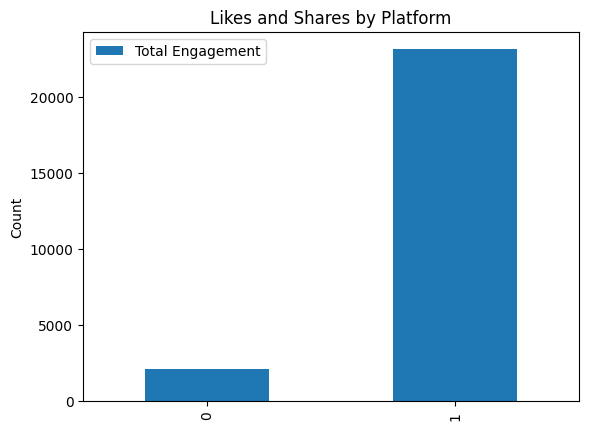

In [4]:
import matplotlib.pyplot as plt

result.plot(kind='bar')
plt.title("Likes and Shares by Platform")
plt.ylabel("Count")
plt.show()